# CARA Úkol 02 — Slovensko: HDP, Nezamestnanosť a Okunov zákon

**Predmet:** Časové rady (CARA) | **Tím:** S22

## Prehľad projektu

Analyzujeme dve štvrťročné časové rady pre Slovensko (1998 Q1 – 2025 Q4):
- **Reálne HDP** — séria `CLVMNACNSAB1GQSK` (Eurostat via FRED), sezónne očistené manuálne
- **Miera nezamestnanosti** — séria `LRHUTTTTSKQ156S` (OECD via FRED), sezónne očistená

**Štruktúra analýzy:**
1. **Príklad 1** — Stacionarita: ADF, KPSS, AR modely, CUSUM, Chow, Zivot-Andrews
2. **Príklad 2** — Dekompozícia trendu: HP filter, polynóm, polynóm so zlomom → cyklické zložky
3. **Príklad 3** — Okunov zákon: regresia cyklík, stabilita koeficientu


# Settings - Loading

## Importy

In [2]:
from fredapi import Fred

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss # ADF a KPSS testy
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.stats.diagnostic import breaks_cusumolsresid # cusum test na reziduách
from statsmodels.tsa.stattools import zivot_andrews
from scipy import stats

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
os.makedirs('outputs', exist_ok=True)

---
## Dáta

### Zdroje
| Rad | FRED séria | Zdroj | Sezónne očistenie |
|---|---|---|---|
| Reálne HDP | `CLVMNACNSAB1GQSK` | Eurostat | NSA → manuálne SA |
| Nezamestnanosť | `LRHUTTTTSKQ156S` | OECD | SA (priamo z FRED) |

> **Poznámka k HDP:** Sezónne očistená séria `CLVMNACSAB1GQSK` je dostupná len do Q3 2020. Preto sme stiahli NSA verziu a sezónne ju očistili pomocou aditívnej dekompozície na log-škále.


# Stiahnutie / Načítanie dát

## Stiahnutie dát

- pre sfunkčnenie treba zmeniť z Raw na Code a doplnit API kluc

### Sezónne očistenie HDP

Sezónne očistenie využíva **aditívnu dekompozíciu na log-škále**, čo je ekvivalentné multiplikatívnej dekompozícii na úrovniach:

$$\log(y_t) = \log(T_t) + \log(S_t) + \log(\varepsilon_t)$$

Sezónne očistený rad: $y_t^{SA} = \exp(\log(y_t) - \hat{S}_t)$

kde $\hat{S}_t$ je odhadnutá sezónna zložka (opakujúca sa každé 4 štvrťroky).

**Overenie:** Porovnanie nášho SA radu s oficiálnym FRED SA radom (do 2020) ukazuje takmer dokonalú zhodu.


sezonne ocistene data boli len do roku 2020, preto som stiahla sezonne neocistene, ktore su do 2025 a sezonne ich ocistila

### Sezonne neocistene data

![](outputs\comparison_gdp.png)

## Načítanie dát zo súboru

In [5]:
# Nacitanie zo suboru

df = pd.read_csv('data.csv', index_col = 'Date', parse_dates = True)
df.index.freq = 'QS' # stvrtrocna frekvencia

In [6]:
df.head()

,GDP,UNEMP
Date,,
1998-01-01,10938.786679,12.16667
1998-04-01,10735.059581,12.33333
1998-07-01,10079.567473,13.03333
1998-10-01,10467.282079,13.36667
1999-01-01,11064.115318,14.80000


In [7]:
df.tail()

,GDP,UNEMP
Date,,
2024-10-01,23748.653588,5.200000
2025-01-01,23259.407451,5.233333
2025-04-01,23433.059399,5.333333
2025-07-01,23601.389142,5.466667
2025-10-01,23991.205348,5.700000


In [8]:
print(f'\nPočet pozorovaní: {len(df)}')
print(f'Obdobie: {df.index[0].date()} až {df.index[-1].date()}')


Počet pozorovaní: 112
Obdobie: 1998-01-01 až 2025-10-01


In [9]:
df['log_GDP'] = np.log(df['GDP'])
df.head()

,GDP,UNEMP,log_GDP
Date,,,
1998-01-01,10938.786679,12.16667,9.300070
1998-04-01,10735.059581,12.33333,9.281270
1998-07-01,10079.567473,13.03333,9.218266
1998-10-01,10467.282079,13.36667,9.256010
1999-01-01,11064.115318,14.80000,9.311462


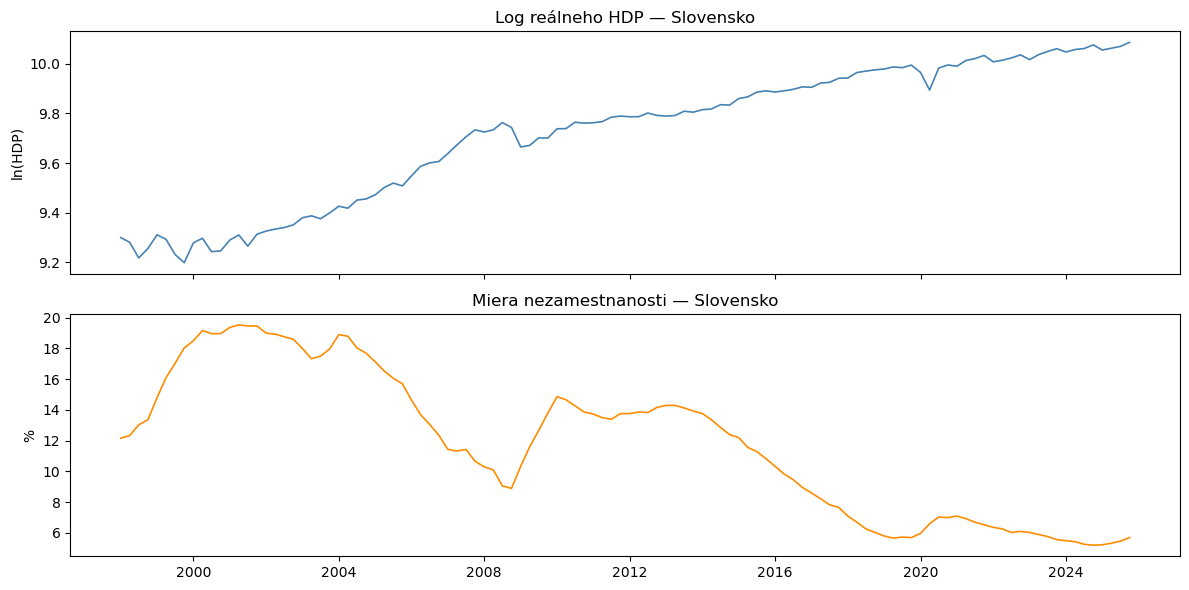

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.log_GDP, color='steelblue', linewidth=1.2)
axes[0].set_title('Log reálneho HDP — Slovensko', fontsize=12)
axes[0].set_ylabel('ln(HDP)')

axes[1].plot(df.UNEMP, color='darkorange', linewidth=1.2)
axes[1].set_title('Miera nezamestnanosti — Slovensko', fontsize=12)
axes[1].set_ylabel('%')

plt.tight_layout()
plt.savefig('outputs\prepared_data_plot.png', dpi=150)
plt.show()

## Globálne premenné

In [11]:
COVID_BREAK = '2020-04-01'
FINANCE_BREAK = '2008-07-01'

---
# Príklad 1: Stacionarita časových radov

## Postup analýzy

```
1. ACF/PACF  →  vizuálna diagnostika pamäti a štruktúry radu
2. ADF test  →  H₀: jednotkový koreň (nestacionárny)
3. KPSS test →  H₀: rad JE stacionárny  (opačná H₀!)
4. Kombinácia výsledkov → rozhodnutie o transformácii
5. Testy na diferenciách → overenie I(1)
6. AR model → výber rádu pre testovanie zlomu
7. CUSUM + Chow test → štrukturálny zlom v AR modeli
8. Zivot-Andrews → jednotkový koreň so zlomom
```

## Matematické pozadie ADF testu

Vychádza z AR(1) modelu prepísaného do testovateľnej formy:

$$\Delta y_t = \rho \, y_{t-1} + \sum_{i=1}^{p} \gamma_i \Delta y_{t-i} + \varepsilon_t$$

kde $\rho = \phi - 1$. **H₀:** $\rho = 0$ (jednotkový koreň). T-štatistika pre $\hat{\rho}$ má neštandardné Dickey-Fullerovo rozdelenie.

Parametre `regression`: `'c'` = len konštanta, `'ct'` = konštanta + lineárny trend.

## Matematické pozadie KPSS testu

Testuje opačnú hypotézu. Rad sa rozloží ako:

$$y_t = \xi t + r_t + \varepsilon_t, \quad r_t = r_{t-1} + u_t, \quad u_t \sim (0, \sigma^2_u)$$

**H₀:** $\sigma^2_u = 0$ (stacionárny). Testovacia štatistika:

$$\text{KPSS} = \frac{1}{T^2} \frac{\sum_{t=1}^{T} S_t^2}{\hat{\sigma}^2_{HAC}}, \quad S_t = \sum_{i=1}^{t} \hat{e}_i$$

kde $\hat{\sigma}^2_{HAC}$ je Newey-West odhad rozptylu (koriguje autokoreláciu rezíduí).


# Príklad 1: Stacionarita

## ACF/PACF vizualizácia

**ACF** (Autocorrelation Function) — korelácia radu so svojimi oneskoreniami.
**PACF** (Partial ACF) — korelácia pri danom lagu *po odstránení* vplyvu kratších lagov.

**Čo hľadáme:**
- **Nestacionárny rad** → ACF pomaly klesá (autokorelačné koeficienty zostávajú vysoké)
- **AR(p) štruktúra** → PACF ostro odpadne po lagu $p$


## ACF/PACF vizualizácia

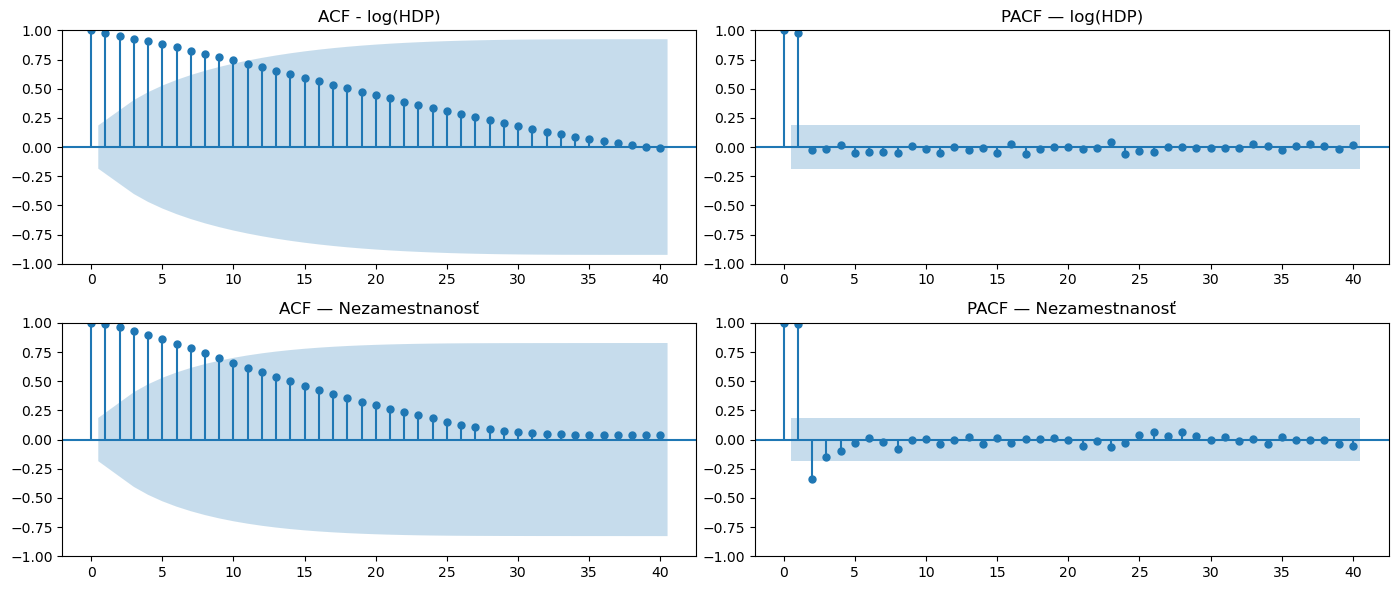

In [12]:
# oba rady (úroveň + ACF/PACF)
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# log_GDP - ACF
plot_acf(df.log_GDP, lags = 40, ax = axes[0, 0], title = 'ACF - log(HDP)')

# log_GDP - PACF
plot_pacf(df.log_GDP, lags=40, ax=axes[0,1], title='PACF — log(HDP)')

# UNEMP - ACF
plot_acf(df.UNEMP, lags=40, ax=axes[1,0], title='ACF — Nezamestnanosť')

# UNEMP - PACF
plot_pacf(df.UNEMP, lags=40, ax=axes[1,1], title='PACF — Nezamestnanosť')

plt.tight_layout()
plt.savefig('outputs/acf_pacf_plot.png', dpi=150)
plt.show()

**log(HDP)**

- ACF veľmi pomalý pokles, nie je jasné, či ide o stacionaritu s vysokým koeficientom alebo o nestacionaritu s jednotkovým koreňom
- PACF - veľmi vysoký hrot (spike) na lagu 1, potom okamžite 0. To naznačuje AR(1) štruktúru


**UNEMP**
- ACF velmi podobne ako HDP
- PACF spike na lagu 1, potom menší opačný na lagu 2, potom 0. To naznačuje AR(2) štruktúru

## ADF test — úrovne

Pre rady s trendom používame `regression='ct'` (konštanta + lineárny trend). Pre rady bez trendu `regression='c'`.

> **Pravidlo:** Úrovne (log_GDP, UNEMP) → `'ct'` | Diferencie → `'c'`


## ADF test

In [14]:
def run_adfuller(data, name='', parameter = 'ct'):
    result = adfuller(data, autolag = 'AIC', regression = parameter)
    print(f'Test: {name}')
    print(f'Testova statistika: {result[0]:.4f}')
    print(f'p-value:{result[1]:.4g}')
    print(f'Počet lagov (AIC)  : {result[2]}')
    print(f'Kritické hodnoty   : {result[4]}')

In [15]:
run_adfuller(df.log_GDP, 'ADF test pre log(HDP), ct:')

Test: ADF test pre log(HDP), ct:
Testova statistika: -0.8661
p-value:0.9596
Počet lagov (AIC)  : 2
Kritické hodnoty   : {'1%': np.float64(-4.044322283462378), '5%': np.float64(-3.4515644781777084), '10%': np.float64(-3.151118741781072)}


In [16]:
run_adfuller(df.log_GDP, 'ADF test pre log(HDP), c:', 'c')

Test: ADF test pre log(HDP), c:
Testova statistika: -1.5723
p-value:0.4975
Počet lagov (AIC)  : 2
Kritické hodnoty   : {'1%': np.float64(-3.49181775886872), '5%': np.float64(-2.8884437992971588), '10%': np.float64(-2.5811201893779985)}


**ADF test pre log(HDP)**

- H0: $\rho = 0$ jednotkový koreň
- nezamietame, teda plati H0, rad má jednotkový koreň, **log(HDP)** je nestacionárny rad (aj pre parameter *c*, aj pre *ct* - t.j. s lineárnym trendom)
- Aj po zohľadnení deterministického trendu ADF stále nezamieta H₀ — teda log(HDP) vykazuje jednotkový koreň aj keď "odčítame" trend. To je silnejší a správnejší záver ako s 'c'.

In [17]:
run_adfuller(df.UNEMP, 'ADF test pre UNEMP, ct:')

Test: ADF test pre UNEMP, ct:
Testova statistika: -3.0076
p-value:0.13
Počet lagov (AIC)  : 6
Kritické hodnoty   : {'1%': np.float64(-4.047684391534392), '5%': np.float64(-3.4531621209372636), '10%': np.float64(-3.1520501036605117)}


In [18]:
run_adfuller(df.UNEMP, 'ADF test pre UNEMP, c:', 'c')

Test: ADF test pre UNEMP, c:
Testova statistika: -1.3628
p-value:0.6
Počet lagov (AIC)  : 6
Kritické hodnoty   : {'1%': np.float64(-3.4942202045135513), '5%': np.float64(-2.889485291005291), '10%': np.float64(-2.5816762131519275)}


**ADF test pre UNEMP**

- H0: $\rho = 0$ jednotkový koreň
- nezamietame, teda plati H0, rad má jednotkový koreň, **UNEMP** je nestacionárny rad (aj pre parameter *c*, aj pre *ct* - t.j. s lineárnym trendom)
- pre *ct* je p-hodnota nižšia, teda nestacionarita má dva zdroje:
    - deterministický (dlhodobý štrukturálny pokles nezamestnanosti) - pri parametri *ct* sa p-hodnota znížila z 0,6 mna 0,16
    - stochastický (jednotkový koreň - náhodné blúdenie)

## KPSS test — úrovne

**Pozor na opačnú H₀:** KPSS zamieta stacionaritu (veľká štatistika = zamietnutie), ADF zamieta nestacionaritu (veľmi záporná štatistika = zamietnutie).

| ADF | KPSS | Záver |
|---|---|---|
| nezamieta H₀ | zamieta H₀ | **nestacionárny** ✅ |
| zamieta H₀ | nezamieta H₀ | **stacionárny** ✅ |
| nezamieta H₀ | nezamieta H₀ | nejasné 🤔 |
| zamieta H₀ | zamieta H₀ | nejasné 🤔 |


## KPSS test

In [19]:
def run_kpss(data, name='', parameter = 'ct'):
    result = kpss(data, regression = parameter, nlags = 'auto')
    print(f'Test: {name}')
    print(f'Testova statistika: {result[0]:.4f}')
    print(f'p-value:{result[1]:.4g}')
    print(f'Počet lagov použitých pre HAC: {result[2]}')
    print(f'Kritické hodnoty   : {result[3]}')

In [20]:
run_kpss(df.log_GDP, 'KPSS test pre log(HDP)', parameter = 'ct')

Test: KPSS test pre log(HDP)
Testova statistika: 0.3334
p-value:0.01
Počet lagov použitých pre HAC: 6
Kritické hodnoty   : {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


In [21]:
run_kpss(df.log_GDP, 'KPSS test pre log(HDP)', parameter = 'c')

Test: KPSS test pre log(HDP)
Testova statistika: 1.6237
p-value:0.01
Počet lagov použitých pre HAC: 6
Kritické hodnoty   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


**KPSS test pre log(HDP)**

- H0: $\sigma^2 = 0$ rad je stacionárny
- zamietame H0, teda plati H1, rad **log(HDP)** nie je stacionárny rad (aj pre parameter *c*, aj pre *ct* - t.j. s lineárnym trendom)
- Aj po zohľadnení deterministického trendu KPSS stále zamieta H₀ — teda log(HDP) je nestacionárny

In [22]:
run_kpss(df.UNEMP, 'KPSS test pre UNEMP', parameter='ct')

Test: KPSS test pre UNEMP
Testova statistika: 0.0861
p-value:0.1
Počet lagov použitých pre HAC: 6
Kritické hodnoty   : {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


In [23]:
run_kpss(df.UNEMP, 'KPSS test pre UNEMP', parameter='c')

Test: KPSS test pre UNEMP
Testova statistika: 1.3696
p-value:0.01
Počet lagov použitých pre HAC: 6
Kritické hodnoty   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


**KPSS test pre UNEMP**

- H0: $\sigma^2 = 0$ rad je stacionárny
- okolo strednej hodnoty zamietame stacionaritu (p = 0.01), ale okolo deterministického trendu nezamietame stacionaritu (p = 0.1)
- tu trochu rozpor s ADF. ten nezamietol v oboch prípadoch,
  - teda podľa ADF je UNEMP nestacionárny
  - podľa KPSS je nestacionárny okolo strednej hodnoty, ale stacionárny okolo deterministického trendu

## Transformácia na stacionárne rady

Z výsledkov ADF a KPSS pre úrovne: **oba rady sú nestacionárne** (resp. pre UNEMP mierny konflikt — KPSS s `'ct'` naznačuje možnú trend-stacionaritu).

**Rozhodnutie:** Prvá diferencia ako štandardná transformácia pre I(1) procesy:
- $\Delta \log(\text{HDP}_t) = \log(\text{HDP}_t) - \log(\text{HDP}_{t-1})$ ≈ štvrťročný percentuálny rast
- $\Delta \text{UNEMP}_t = \text{UNEMP}_t - \text{UNEMP}_{t-1}$ = zmena v percentuálnych bodoch

Pre diferencované rady používame `regression='c'` (trend bol odstránený diferenciou).


## Testy na diferenciách

Z predch: log_GDP je nestacionarny (podla oboch testov, aj oboch parametrov)

UNEMP - tu je to neiste, ci nestacionarita nie je len z trendu

In [24]:
df['d_log_GDP'] = df.log_GDP.diff()
df['d_UNEMP']   = df.UNEMP.diff()

### HDP diferencia

In [25]:
run_adfuller(df['d_log_GDP'].dropna(), 'ADF test pre diff log(HDP), c:', 'c')

Test: ADF test pre diff log(HDP), c:
Testova statistika: -12.0067
p-value:3.251e-22
Počet lagov (AIC)  : 1
Kritické hodnoty   : {'1%': np.float64(-3.49181775886872), '5%': np.float64(-2.8884437992971588), '10%': np.float64(-2.5811201893779985)}


In [26]:
run_adfuller(df['d_log_GDP'].dropna(), 'ADF test pre diff log(HDP), c:', 'ct')

Test: ADF test pre diff log(HDP), c:
Testova statistika: -12.1333
p-value:2.354e-19
Počet lagov (AIC)  : 1
Kritické hodnoty   : {'1%': np.float64(-4.044322283462378), '5%': np.float64(-3.4515644781777084), '10%': np.float64(-3.151118741781072)}


In [27]:
run_kpss(df['d_log_GDP'].dropna(), 'KPSS test pre diff(HDP), c:', 'c')

Test: KPSS test pre diff(HDP), c:
Testova statistika: 0.1344
p-value:0.1
Počet lagov použitých pre HAC: 27
Kritické hodnoty   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [28]:
run_kpss(df['d_log_GDP'].dropna(), 'KPSS test pre diff(HDP), c:', 'ct')

Test: KPSS test pre diff(HDP), c:
Testova statistika: 0.1130
p-value:0.1
Počet lagov použitých pre HAC: 29
Kritické hodnoty   : {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


Oba testy zhodne pre oba parametre: **d_log(HDP)** je stacionánrny rad --> **log(HDP) je I(1)**

### UNEMP diferencia

In [29]:
run_adfuller(df['d_UNEMP'].dropna(), 'ADF test pre diff UNEMP, c:', 'c')

Test: ADF test pre diff UNEMP, c:
Testova statistika: -3.5780
p-value:0.006197
Počet lagov (AIC)  : 7
Kritické hodnoty   : {'1%': np.float64(-3.4954932834550623), '5%': np.float64(-2.8900369024285117), '10%': np.float64(-2.5819706975209726)}


In [30]:
run_kpss(df['d_UNEMP'].dropna(), 'KPSS test pre UNEMP, c:', 'c')

Test: KPSS test pre UNEMP, c:
Testova statistika: 0.1894
p-value:0.1
Počet lagov použitých pre HAC: 5
Kritické hodnoty   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


Oba testy zhodne: **d_log(HDP)** je stacionárny rad --> **log(HDP) je I(1)**

Na základe ADF a KPSS testov oba rady (log HDP, miera nezamestnanosti) vykazujú jednotkový koreň — sú I(1). Stacionaritu dosahujeme prvou diferenciou.

## AR model na stacionárnych radoch

AR(p) model:
$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

Rád $p$ vyberáme na základe **PACF** — spike na lagu $p$, potom nula — a porovnáme **AIC**.

Modely potrebujeme pre test štrukturálneho zlomu (CUSUM operuje na rezíduách AR modelu).


## AR model

In [31]:
y_gdp   = df.d_log_GDP.dropna()
y_unemp = df.d_UNEMP.dropna()

### AR model pre log_HDP

In [32]:
ar_1_gdp = AutoReg(y_gdp, lags = 1).fit()
ar_1_gdp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:              d_log_GDP   No. Observations:                  111
Model:                     AutoReg(1)   Log Likelihood                 249.209
Method:               Conditional MLE   S.D. of innovations              0.025
Date:                Wed, 13 May 2026   AIC                           -492.418
Time:                        15:43:02   BIC                           -484.316
Sample:                    07-01-1998   HQIC                          -489.132
                         - 10-01-2025                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0076      0.002      3.062      0.002       0.003       0.012
d_log_GDP.L1    -0.0423      0.095     -0.446      0.655      -0.228       0.144
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1          -23.6176           +0.0000j           23.6176            0.5000
-----------------------------------------------------------------------------
"""

const = 0.0076 (p = 0.002)

- priemerný štvrťročný rast je 0,76%, štatisticky významný

AR(1) koeficient = -0.0423 (p = 0.655)

- koeficient je nevýznamný, možno aj 0,
- d_log(HDP) sa správa ako biely šum

AR(1) koeficient je blízky nule a nevýznamný — teda minulý rast HDP nepomáha predpovedať budúci rast. d_log_GDP sa správa takmer ako biely šum okolo konštantnej strednej hodnoty 0.76%.

Koreň AR polynómu je 23.6 — ďaleko od jednotkového kruhu (modulus >> 1), čo potvrdzuje stacionaritu diferencovaného radu.


Pre test štrukturálneho zlomu môžno použiť aj jednoduchší model AR(0) — teda len konštantu bez lagov.

In [33]:
ar_0_gdp = AutoReg(y_gdp, lags = 0). fit()
ar_0_gdp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:              d_log_GDP   No. Observations:                  111
Model:                     AutoReg(0)   Log Likelihood                 251.339
Method:               Conditional MLE   S.D. of innovations              0.025
Date:                Wed, 13 May 2026   AIC                           -498.679
Time:                        15:43:04   BIC                           -493.260
Sample:                    04-01-1998   HQIC                          -496.480
                         - 10-01-2025                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0071      0.002      2.965      0.003       0.002       0.012
==============================================================================
"""

AR(0) ma nizsie AIC, koeficient v AR(1) je nevyznamny, preto je lepsie dalej pracovat s AR(0)

### AR model pre UNEMP

In [34]:
ar_2_unemp = AutoReg(y_unemp, lags = 2).fit()
ar_2_unemp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                d_UNEMP   No. Observations:                  111
Model:                     AutoReg(2)   Log Likelihood                 -43.269
Method:               Conditional MLE   S.D. of innovations              0.360
Date:                Wed, 13 May 2026   AIC                             94.537
Time:                        15:43:06   BIC                            105.303
Sample:                    10-01-1998   HQIC                            98.903
                         - 10-01-2025                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0236      0.035     -0.678      0.497      -0.092       0.045
d_UNEMP.L1     0.7224      0.095      7.635      0.000       0.537       0.908
d_UNEMP.L2    -0.0290      0.095     -0.307      0.759      -0.214       0.156
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.4713           +0.0000j            1.4713            0.0000
AR.2           23.4104           +0.0000j           23.4104            0.0000
-----------------------------------------------------------------------------
"""

- const = -0.0236 — priemerná zmena nezamestnanosti je mierne záporná (klesá), ale nevýznamná (p = 0.497)
- d_UNEMP.L1 = 0.7224 — silný a vysoko významný (p = 0.000) — minulá zmena nezamestnanosti silne predpovedá súčasnú
- d_UNEMP.L2 = -0.0290 — prakticky nula, nevýznamný (p = 0.759)

AR(2) koeficient je nevýznamný — model sa de facto redukuje na AR(1).

In [35]:
ar_1_unemp = AutoReg(y_unemp, lags = 1).fit()
ar_1_unemp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                d_UNEMP   No. Observations:                  111
Model:                     AutoReg(1)   Log Likelihood                 -44.607
Method:               Conditional MLE   S.D. of innovations              0.363
Date:                Wed, 13 May 2026   AIC                             95.215
Time:                        15:43:08   BIC                            103.316
Sample:                    07-01-1998   HQIC                            98.501
                         - 10-01-2025                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0173      0.035     -0.495      0.620      -0.086       0.051
d_UNEMP.L1     0.7067      0.068     10.462      0.000       0.574       0.839
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.4151           +0.0000j            1.4151            0.0000
-----------------------------------------------------------------------------
"""

model AR(1) je takmer rovnako dobrý podla metriky AIC, okrem toho koeficient AR.2 je nevýznamný, preto ďalej radšej použiť AR(1)

**d_log_GDP** — AR(1) koeficient nevýznamný -> prakticky AR(0), teda biely šum okolo konštanty

**d_UNEMP** — AR(1) koeficient vysoko významný (0.72) -> AR(1) má zmysel

Pre test štrukturálneho zlomu to znamená:

- pre d_log_GDP testujeme zlom v konštante (priemernom raste HDP)
- pre d_UNEMP testujeme zlom v konštante aj AR(1) koeficiente

## Štrukturálny zlom v AR modeli

### CUSUM test
Testuje stabilitu parametrov AR modelu prehľadaním **celého** časového obdobia (nie je potrebné fixovať bod zlomu).

Testovacia štatistika:
$$\text{CUSUM} = \max_t \left| \frac{S_t}{\sqrt{T}} \right|, \quad S_t = \sum_{i=1}^{t} \frac{\hat{e}_i}{\hat{\sigma}}$$

**H₀:** parametre sú stabilné. Veľká štatistika → zamietnutie.

### Chow test (pre známy bod zlomu)
Porovnáva RSS celého modelu vs. RSS dvoch samostatných modelov:

$$F = \frac{(RSS_{pool} - RSS_1 - RSS_2) / k}{(RSS_1 + RSS_2) / (T - 2k)} \sim F(k, T-2k)$$

kde $k$ = počet parametrov. Testujeme body: **2008Q3** (finančná kríza) a **2020Q2** (covid na SR).


## Štrukturálny zlom v AR

In [36]:
# CUSUM test na rezíduách
stat, pvalue, _ = breaks_cusumolsresid(ar_0_gdp.resid)
print(f'CUSUM stat pre diff log_GDP: {stat:.4f}, p-value: {pvalue:.4g}')

CUSUM stat pre diff log_GDP: 0.6251, p-value: 0.8294


In [37]:
stat, pvalue, _ = breaks_cusumolsresid(ar_1_unemp.resid)
print(f'CUSUM stat pre diff UNEMP: {stat:.4f}, p-value: {pvalue:.4g}')

CUSUM stat pre diff UNEMP: 0.7526, p-value: 0.6228


### Chow test manuálne

In [38]:
def rss(y):
    return ((y - y.mean())**2).sum()

In [39]:
def run_Chow(y, break_date, k):
    y_1 = y[y.index < break_date]
    y_2 = y[y.index >= break_date]
    RSS_pool = rss(y)
    RSS_1 = rss(y_1)
    RSS_2 = rss(y_2)
    
    T = len (y)
    F = ((RSS_pool - RSS_1 - RSS_2)/k)/((RSS_1 + RSS_2)/(T - 2*k))

    pvalue = 1 - stats.f.cdf(F, k, T - 2*k)
    print(f'Chow test for {break_date}, F-stat: {F:.4f}, p-value: {pvalue:.4g}')
    

In [40]:
run_Chow(y_gdp, '2020-04-01', 1) # pre AR(0) je pocet koeficientov 1

Chow test for 2020-04-01, F-stat: 0.1480, p-value: 0.7012


In [41]:
run_Chow(y_unemp, '2020-04-01', 2) # pre AR(1) je pocet koeficientov 2

Chow test for 2020-04-01, F-stat: 0.1169, p-value: 0.8898


In [42]:
run_Chow(y_gdp, '2008-10-01', 1) # pre AR(0) je pocet koeficientov 1

Chow test for 2008-10-01, F-stat: 1.6562, p-value: 0.2008


In [43]:
run_Chow(y_unemp, '2008-10-01', 1) # pre AR(1) je pocet koeficientov 2

Chow test for 2008-10-01, F-stat: 0.0615, p-value: 0.8046


Žiadny štrukturálny zlom v AR modeloch pre oba stacionárne rady.

To je ekonomicky zaujímavý výsledok — napriek dramatickým udalostiam (finančná kríza 2008, covid 2020) sa dynamika (teda AR štruktúra) radu nezmenila. Šoky boli veľké, ale dočasné — systém sa vrátil k rovnakému správaniu.

## Zivot-Andrews test

**Motivácia:** Štandardný ADF má slabú silu ak rad obsahuje štrukturálny zlom v trende — môže nesprávne nezamietnuť H₀.

**Idea:** Prehľadá všetky možné body zlomu $\tau$ a vyberie ten, kde je ADF štatistika najzápornejšia:
$$\hat{\tau} = \arg\min_\tau \, t_{\rho}(\tau)$$

**Model C** (zlom v konštante aj trende):
$$\Delta y_t = \rho y_{t-1} + c + \beta t + \delta \cdot DU_t + \gamma \cdot DT_t + \sum \phi_i \Delta y_{t-i} + \varepsilon_t$$

kde $DU_t = \mathbf{1}(t \geq \tau)$ a $DT_t = (t-\tau) \cdot \mathbf{1}(t \geq \tau)$.

**H₀:** $\rho = 0$ (jednotkový koreň aj po zahrnutí zlomu).

> **Pozor na bug v statsmodels:** `zivot_andrews()` modifikuje vstupnú Series inplace → vždy volať s `.copy()`.


## Zivot-Andrews

log_GDP a UNEMP sa ukazali podla ADF ako nestacionarne, preverime, ci nahodou nestacionarita nie je kvoli strukturálnemu zlomu

In [44]:
def run_za(y, name):
    stat, p, krit, _, zlom = zivot_andrews(y.copy()) # chyba, funkcia modifikuje vstup, preto copy
    print(name)
    print(f'Testova statistika: {stat:.4f}')
    print(f'P-hodnota: {p:.4g}')
    print(f'Bod zlomu: {df.index[zlom]}')

In [45]:
run_za(df.log_GDP, 'Zivot-Andrews pre log(HDP):')

Zivot-Andrews pre log(HDP):
Testova statistika: -3.4051
P-hodnota: 0.7381
Bod zlomu: 2004-10-01 00:00:00


In [46]:
run_za(df.UNEMP, 'Zivot-Andrews pre UNEMP:')

Zivot-Andrews pre UNEMP:
Testova statistika: -3.6527
P-hodnota: 0.5796
Bod zlomu: 2008-10-01 00:00:00


**log(HDP)**

Nezamietame H₀ — p-value 0.74 je vysoká, štatistika -3.41 je ďaleko od kritických hodnôt.

Záver: Ani po zahrnutí možného štrukturálneho zlomu nevieme zamietnuť jednotkový koreň pre log_GDP. Teda log_GDP je I(1) — potvrdené.
Bod zlomu 2004Q4 je navyše ekonomicky ťažko interpretovateľný — nie je to ani 2008, ani 2020. To naznačuje že test nenašiel žiadny skutočný zlom, len lokálne minimum štatistiky.

**UNEMP**

Tiež nezamietame H₀ — p-value 0.58 je vysoká.
Záver: Ani pre UNEMP Zivot-Andrews nezamietol jednotkový koreň — napriek tomu že bod zlomu 2008Q4 je ekonomicky zmysluplný (finančná kríza).
    

---
# Príklad 2: Dekompozícia trendu

## Idea

Vrátime sa k **pôvodným nestacionárnym** radom (log_GDP, UNEMP). Cieľ je odhadnúť **rovnovážnu úroveň** (trend) a získať **cyklické odchýlky**:

$$y_t = \tau_t + c_t$$

kde $\tau_t$ je trend (potenciálny produkt / prirodzená miera nezamestnanosti) a $c_t$ je cyklická zložka (výstupná medzera / medzera nezamestnanosti).

## Tri metódy dekompozície

| Metóda | Princíp | Výhody | Nevýhody |
|---|---|---|---|
| **HP filter** | Optimalizácia: hladkosť vs. blízkosť k dátam | Flexibilný, štandardný | Endpoint bias, $\lambda$ je ad hoc |
| **Polynóm** | OLS regresia na $1, t, t^2, t^3$ | Jednoduchý, interpretovateľný | Rigidný, problémy na krajoch |
| **Polynóm + zlom** | Polynóm + dummy premenné pre zlom | Zachytí štrukturálny zlom | Citlivý na voľbu bodu zlomu |


# PRÍKLAD 2: Dekompozícia trendu

V Príklade 1 sme pracovali s diferencovanými radmi aby sme dosiahli stacionaritu. Teraz sa vrátime k pôvodným nestacionárnym radom — log_GDP a UNEMP.
Cieľ je odhadnúť rovnovážnu úroveň každého radu:

- pre log_GDP → potenciálny produkt
- pre UNEMP → prirodzená miera nezamestnanosti

A z toho získať cyklické odchýlky:

- výstupná medzera = log_GDP − potenciálny produkt
- medzera nezamestnanosti = UNEMP − prirodzená miera

## Hodrick-Prescottov filter

Minimalizuje kompromis medzi **blízkosťou k dátam** a **hladkosťou trendu**:

$$\min_{\tau_t} \left\{ \underbrace{\sum_{t=1}^{T} (y_t - \tau_t)^2}_{\text{blízkosť}} + \lambda \underbrace{\sum_{t=2}^{T-1} [(\tau_{t+1} - \tau_t) - (\tau_t - \tau_{t-1})]^2}_{\text{hladkosť (2. diferencia trendu)}} \right\}$$

**Parameter $\lambda = 1600$** — štandardná hodnota pre štvrťročné dáta (Hodrick & Prescott, 1997).

- $\lambda \to 0$: trend = dáta (cyklika = 0)
- $\lambda \to \infty$: trend = lineárna funkcia času


## HP filter

In [47]:
cycle_log_gdp_hp, trend_log_gdp_hp = hpfilter(df.log_GDP.dropna(), lamb = 1600)
# cyklicka zlozka je automaticky vypocitana ako y_t - trend_t

In [48]:
cycle_unemp_hp, trend_unemp_hp = hpfilter(df.UNEMP.dropna(),   lamb=1600)

In [49]:
print(df.log_GDP.head())
print(df.log_GDP.describe())

Date
1998-01-01    9.300070
1998-04-01    9.281270
1998-07-01    9.218266
1998-10-01    9.256010
1999-01-01    9.311462
Freq: QS-JAN, Name: log_GDP, dtype: float64
count    112.000000
mean       9.720906
std        0.271567
min        9.199126
25%        9.467897
50%        9.786269
75%        9.965688
max       10.085443
Name: log_GDP, dtype: float64


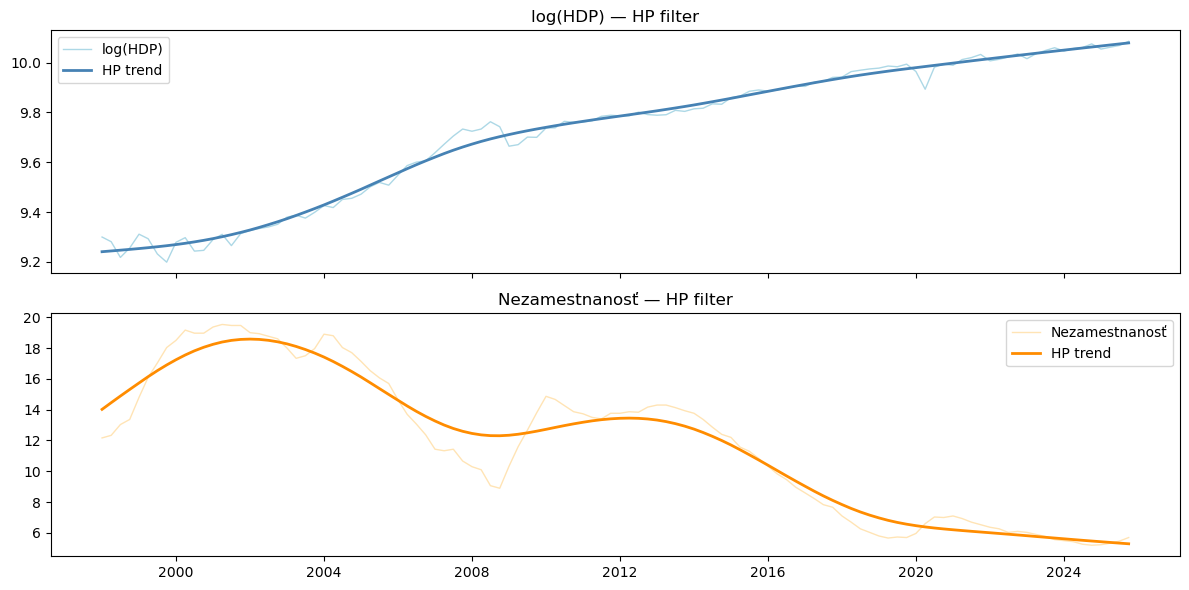

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.log_GDP,   color='lightblue', linewidth=1,   label='log(HDP)')
axes[0].plot(trend_log_gdp_hp,    color='steelblue', linewidth=2,   label='HP trend')
axes[0].set_title('log(HDP) — HP filter')
axes[0].legend()

axes[1].plot(df.UNEMP,     color='moccasin',    linewidth=1,   label='Nezamestnanosť')
axes[1].plot(trend_unemp_hp,  color='darkorange',  linewidth=2,   label='HP trend')
axes[1].set_title('Nezamestnanosť — HP filter')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs\HP_filter.png', dpi=150)
plt.show()

## Polynomiálny trend

OLS regresia $y_t$ na polynóm v čase:

$$y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \beta_3 t^3 + \varepsilon_t$$

Matrica regresorov: $X = [\mathbf{1}, t, t^2, t^3]$, odhad: $\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top \mathbf{y}$

Cyklická zložka = rezíduá: $\hat{c}_t = y_t - \hat{\tau}_t$

**Voľba stupňa:** kubický ($k=3$) — zachytáva nelineárny pokles nezamestnanosti a spomalenie rastu HDP lepšie ako kvadratický.


## Polynomiálny trend

In [51]:
t = np.arange(len(df))

In [52]:
X = sm.add_constant(np.column_stack([t, t**2, t**3]))

In [53]:
# log GDP
model_log_gdp_poly = OLS(df.log_GDP, X).fit()
trend_log_gdp_poly = model_log_gdp_poly.fittedvalues
cycle_log_gdp_poly = df.log_GDP - trend_log_gdp_poly

# UNEMP
model_unemp_poly = OLS(df.UNEMP, X).fit()
trend_unemp_poly = model_unemp_poly.fittedvalues
cycle_unemp_poly = df.UNEMP - trend_unemp_poly

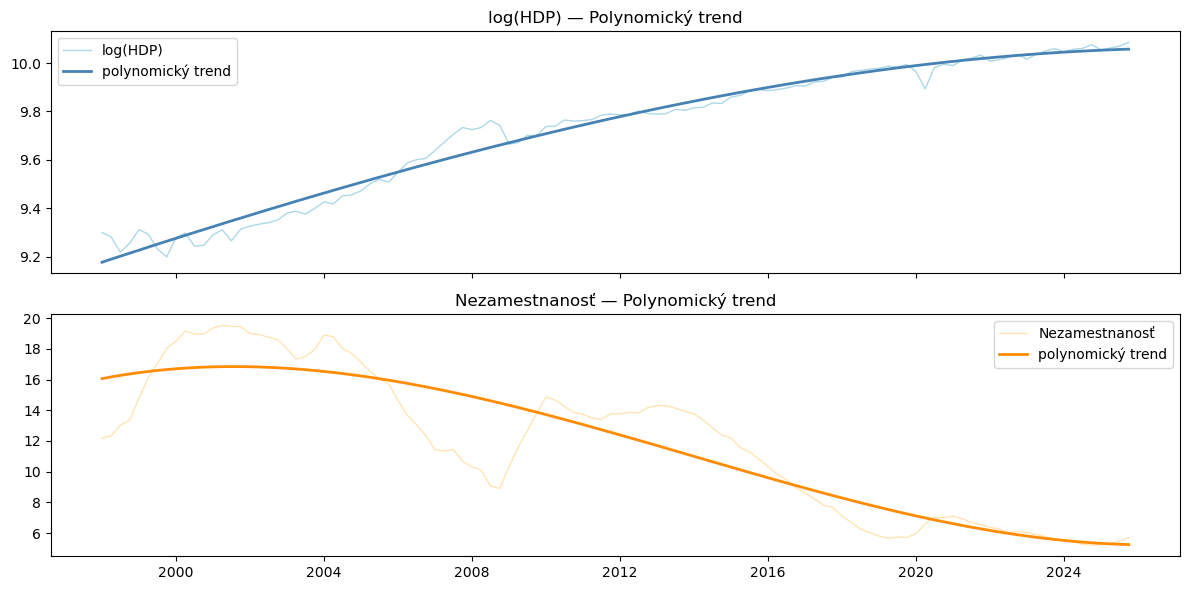

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.log_GDP,   color='lightblue', linewidth=1,   label='log(HDP)')
axes[0].plot(trend_log_gdp_poly,    color='steelblue', linewidth=2,   label='polynomický trend')
axes[0].set_title('log(HDP) — Polynomický trend')
axes[0].legend()

axes[1].plot(df.UNEMP,     color='moccasin',    linewidth=1,   label='Nezamestnanosť')
axes[1].plot(trend_unemp_poly,  color='darkorange',  linewidth=2,   label='polynomický trend')
axes[1].set_title('Nezamestnanosť — Polynomický trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs\poly_trend.png', dpi=150)
plt.show()

## Polynóm so štrukturálnym zlomom

Rozšírenie polynómu o dummy premenné pre bod zlomu $\tau$:

$$y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \delta_0 DU_t + \delta_1 DT_t + \varepsilon_t$$

kde:
- $DU_t = \mathbf{1}(t \geq \tau)$ — skoková zmena úrovne trendu
- $DT_t = (t - \tau) \cdot \mathbf{1}(t \geq \tau)$ — zmena sklonu trendu po zlome

**Body zlomu:**
- **log(HDP):** 2020Q2 (covid — pokles HDP na SR)
- **UNEMP:** 2008Q4 (finančná kríza — prerušenie klesajúceho trendu nezamestnanosti)


## Polynóm so štrukturálnym zlomom

pre nezamestnanosť vyšiel bod zlomu 2008Q4 

Pre log(HDP) môžeme skúsiť 2020Q1

### GDP

In [55]:
# Bod zlomu
break_date_gdp   = COVID_BREAK
df.index.get_loc(break_date_gdp)

89

In [56]:
# Dummy premenne
DU_gdp   = (df.index >= break_date_gdp).astype(int)

DT_gdp   = np.where(df.index >= break_date_gdp,   t - df.index.get_loc(break_date_gdp),   0)
X_gdp_break = sm.add_constant(np.column_stack([t, t**2, DU_gdp, DT_gdp]))

In [57]:
# OLS
model_log_gdp_break = OLS(df.log_GDP, X_gdp_break).fit()
trend_log_gdp_break = model_log_gdp_break.fittedvalues
cycle_log_gdp_break = df.log_GDP - trend_log_gdp_break

### UNEMP

In [58]:
# Bod zlomu
break_date_unemp = FINANCE_BREAK
df.index.get_loc(break_date_unemp)

42

In [59]:
# Dummy premenne
DU_unemp   = (df.index >= break_date_unemp).astype(int)
DT_unemp   = np.where(df.index >= break_date_unemp,   t - df.index.get_loc(break_date_unemp),   0)
X_unemp_break = sm.add_constant(np.column_stack([t, t**2, t**3, DU_unemp, DT_unemp]))

In [60]:
# OLS
model_unemp_break = OLS(df.UNEMP, X_unemp_break).fit()
trend_unemp_break = model_unemp_break.fittedvalues
cycle_unemp_break = df.UNEMP - trend_unemp_break

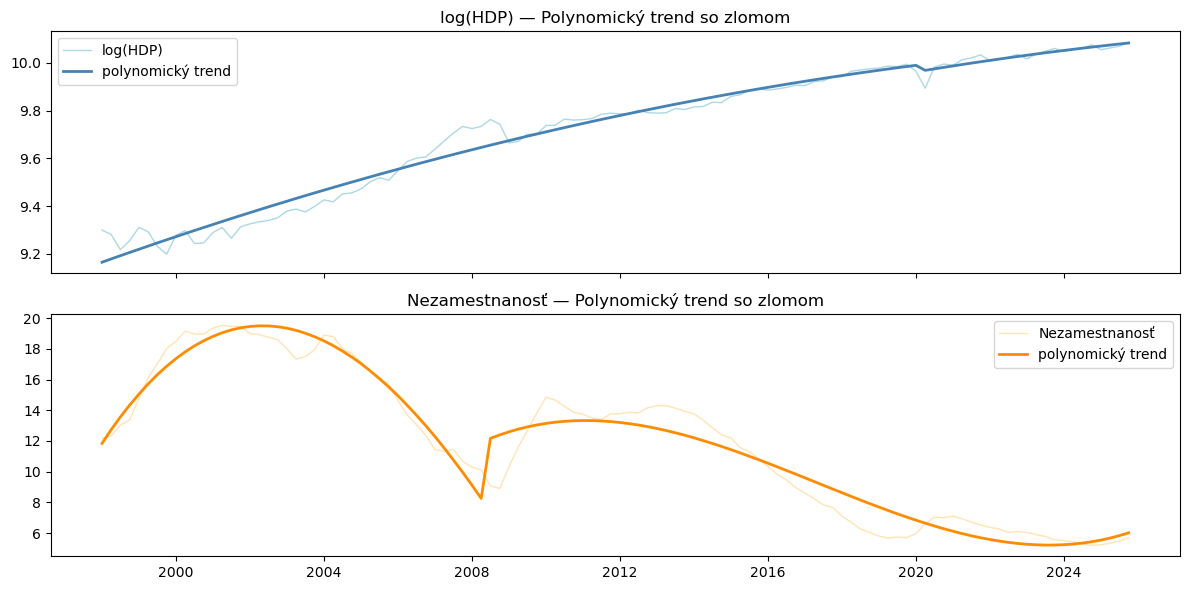

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.log_GDP,   color='lightblue', linewidth=1,   label='log(HDP)')
axes[0].plot(trend_log_gdp_break,    color='steelblue', linewidth=2,   label='polynomický trend')
axes[0].set_title('log(HDP) — Polynomický trend so zlomom')
axes[0].legend()

axes[1].plot(df.UNEMP,     color='moccasin',    linewidth=1,   label='Nezamestnanosť')
axes[1].plot(trend_unemp_break,  color='darkorange',  linewidth=2,   label='polynomický trend')
axes[1].set_title('Nezamestnanosť — Polynomický trend so zlomom')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs\poly_zlom.png', dpi=150)
plt.show()

vidieť jasný efekt štrukturálneho zlomu:

- log(HDP) — trend vyzerá podobne ako bez zlomu, covid zlom v 2020Q2 je sotva viditeľný — čo dáva zmysel, HDP sa rýchlo zotavilo.
- Nezamestnanosť — tu je zlom v 2008Q3 výrazne viditeľný — trend sa skokovo posunie nadol a zmení sklon. Ekonomicky zmysluplné — finančná kríza prerušila dovtedajší pokles nezamestnanosti.

## Porovnanie cyklických zložiek

Každá metóda produkuje inú cykliku — porovnáme ich pomocou:
1. **Vizualizácie** — všetky tri cykliky na jednom grafe
2. **Korelačnej matice** — kvantitatívna miera podobnosti
3. **Podiel súhlasných období** — ako robustná je identifikácia recesií/boomov


## Porovnanie cyklických zložiek

In [63]:
 df_cycles_gdp = pd.DataFrame({
     'HP filter'      : cycle_log_gdp_hp,
     'Polynóm'        : cycle_log_gdp_poly,
     'Polynóm + zlom' : cycle_log_gdp_break,
 }, index=df.index)


In [64]:
df_cycles_unemp = pd.DataFrame({
    'HP filter'      : cycle_unemp_hp,
    'Polynóm'        : cycle_unemp_poly,
    'Polynóm + zlom' : cycle_unemp_break,
}, index=df.index)

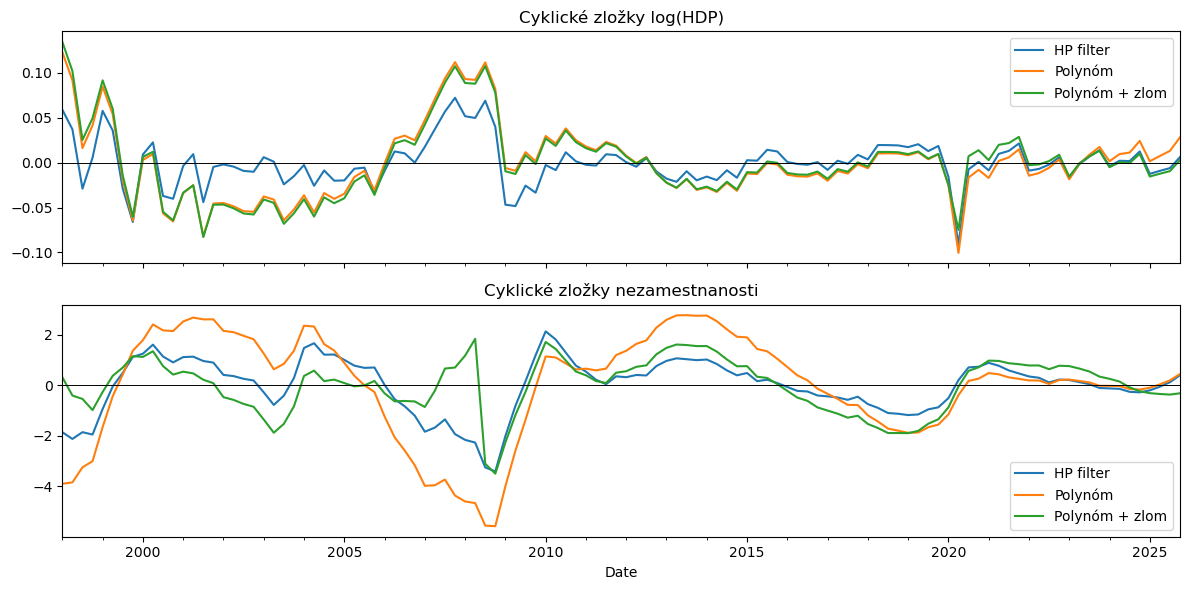

In [65]:
# Vizualizácia
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

df_cycles_gdp.plot(ax=axes[0], title='Cyklické zložky log(HDP)')
axes[0].axhline(0, color='black', linewidth=0.7)

df_cycles_unemp.plot(ax=axes[1], title='Cyklické zložky nezamestnanosti')
axes[1].axhline(0, color='black', linewidth=0.7)

plt.tight_layout()
plt.savefig('outputs\cycles.png', dpi = 150)
plt.show()

- log(HDP) — všetky tri metódy sú veľmi podobné, sledujú rovnaké cyklické pohyby. HP filter má mierne menšie amplitúdy — je hladší trend. Polynóm a polynóm so zlomom sú takmer identické.
- Nezamestnanosť — tu sú rozdiely výraznejšie:
    - Polynóm (oranžová) má veľké odchýlky na začiatku a okolo 2008 — trend nesedí dobre na krajoch
    - HP filter a polynóm so zlomom sú si bližšie — zachytávajú cykliku rozumnejšie
    - Zlom v 2008Q4 výrazne pomáha polynómu so zlomom zachytiť skok nezamestnanosti

##  Korelačná matica

In [66]:
df_cycles_gdp.corr().round(3)

,HP filter,Polynóm,Polynóm + zlom
HP filter,1.000,0.831,0.820
Polynóm,0.831,1.000,0.982
Polynóm + zlom,0.820,0.982,1.000


Polynóm a Polynóm + zlom majú koreláciu 0.98 — takmer identické cykliky. Zlom v 2020Q1 pre HDP teda veľmi nemenil výsledok.
HP filter má nižšiu koreláciu s oboma polynómami (~0.83) — HP filter je flexibilnejší a zachytáva trend inak ako rigidný polynóm.

In [67]:
df_cycles_unemp.corr().round(3)

,HP filter,Polynóm,Polynóm + zlom
HP filter,1.000,0.897,0.653
Polynóm,0.897,1.000,0.512
Polynóm + zlom,0.653,0.512,1.000


tu sú rozdiely oveľa výraznejšie ako pri HDP:

Polynóm + zlom má nízku koreláciu s oboma ostatnými metódami (0.65 a 0.51) — zlom v 2008Q4 dramaticky mení tvar cykliky nezamestnanosti.
HP filter a Polynóm sú si bližšie (0.90) — obe metódy bez zlomu dávajú podobnejší výsledok.

**Čo to hovorí ekonomicky**

Nízka korelácia polynómu so zlomom naznačuje že voľba metódy dekompozície výrazne ovplyvňuje záver pre nezamestnanosť — cyklika nie je robustná. To je dôležitý záver pre sprievodný dokument.
Pre HDP sú metódy konzistentnejšie (0.83–0.98) — výstupná medzera je robustnejšia voči voľbe metódy.

## Recesie a boomy

**Definícia:** Recesia = $c_t < 0$ (ekonomika pod potenciálom), Boom = $c_t > 0$.

Farebné zóny v grafe označujú recesie podľa HP filtra ako referenčnej metódy.

**Robustnosť:** Podiel období kde **všetky tri metódy súhlasia** v klasifikácii recesia/boom.


## Recesie a boomy

Recesia = cyklická zložka HDP < 0(ekonomika pod potenciálom)

Boom = nad potenciálom

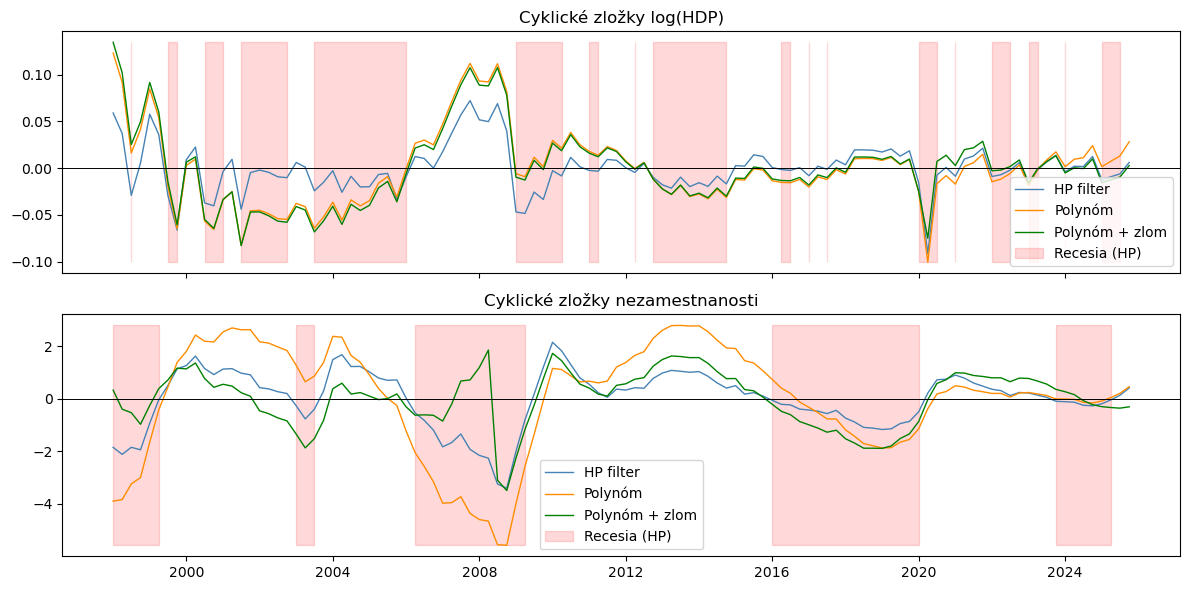

In [68]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, cycle, title in zip(
    axes,
    [df_cycles_gdp, df_cycles_unemp],
    ['Cyklické zložky log(HDP)', 'Cyklické zložky nezamestnanosti']
):
    for col, color in zip(cycle.columns, ['steelblue', 'darkorange', 'green']):
        ax.plot(cycle.index, cycle[col], color=color, linewidth=1, label=col)
    
    # Recesie podla HP filtra
    recession = cycle['HP filter'] < 0
    ax.fill_between(cycle.index, cycle.min().min(), cycle.max().max(),
                    where=recession, alpha=0.15, color='red', label='Recesia (HP)')
    
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('outputs/recession_booms.png', dpi = 150)
plt.show()

In [66]:
for name, cycles in [('log(HDP)', df_cycles_gdp), ('Nezamestnanosť', df_cycles_unemp)]:
    recesie = (cycles < 0)
    # Podiel období kde všetky metódy súhlasia
    vsetky_suhlasia = recesie.all(axis=1) | (~recesie).all(axis=1)
    print(f'{name}: {vsetky_suhlasia.mean():.1%} období kde všetky metódy súhlasia')

log(HDP): 75.0% období kde všetky metódy súhlasia
Nezamestnanosť: 74.1% období kde všetky metódy súhlasia


log(HDP) — 75.0% — tri štvrtiny období sú konzistentne klasifikované všetkými metódami. Pomerne robustný záver o recesiách a boomoch.

Nezamestnanosť — 74.1% — o niečo nižší súhlas, čo zodpovedá nízkym koreláciam cyklík ktoré sme videli — hlavne polynóm so zlomom sa líši od ostatných.


**Záver Príkladu 2**

- Metódy sú konzistentnejšie pre HDP ako pre nezamestnanosť
- Pre nezamestnanosť voľba metódy výrazne ovplyvňuje identifikáciu cyklických zložiek — hlavne zahrnutie štrukturálneho zlomu
- Napriek rozdielom ~74-75% období je klasifikácia recesia/boom konzistentná naprieč metódami

---
# Príklad 3: Okunov zákon

## Ekonomická idea

**Okunov zákon** (Arthur Okun, 1962) — empirický vzťah medzi výstupnou medzerou a medzerou nezamestnanosti:

> *Keď je ekonomika nad potenciálom, nezamestnanosť je pod prirodzenou mierou.*

## Regresný model

$$u^c_t = \alpha \, y^c_t + \varepsilon_t$$

kde $u^c_t$ je medzera nezamestnanosti (p.b.), $y^c_t$ je výstupná medzera (%), $\alpha < 0$ je Okunov koeficient.

**Bez konštanty** — obe cykliky sú odchýlky od rovnováhy, teda v rovnováhe sú obe nula.

> **Pozor na jednotky:** $y^c_t$ je v log jednotkách (0.01 ≈ 1%), preto násobíme × 100 aby koeficient bol interpretovateľný ako „zmena v p.b. na 1% výstupnej medzery".

## Postup
1. OLS odhad $\alpha$ pre každú metódu dekompozície (s HAC štandardnými chybami)
2. Chow test stability $\alpha$ okolo krízy 2008Q3 a covidu 2020Q2
3. Rozšírený model s dummy premennými pre zlom


# PRÍKLAD 3: Okunov zákon

## OLS Okunov koeficient

In [67]:
X = cycle_log_gdp_hp * 100
y = cycle_unemp_hp

In [68]:
model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            UNEMP_cycle   R-squared (uncentered):                   0.289
Model:                            OLS   Adj. R-squared (uncentered):              0.283
Method:                 Least Squares   F-statistic:                              45.21
Date:                Wed, 13 May 2026   Prob (F-statistic):                    7.99e-10
Time:                        14:22:09   Log-Likelihood:                         -145.64
No. Observations:                 112   AIC:                                      293.3
Df Residuals:                     111   BIC:                                      296.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
log_GDP_cycle    -0.2275      0.034     -6.724      0.000      -0.295      -0.160
==============================================================================
Omnibus:                       13.243   Durbin-Watson:                   0.524
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               16.441
Skew:                          -0.655   Prob(JB):                     0.000269
Kurtosis:                       4.344   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Interpretácia:** Ak sa výstupná medzera zvýši o 1%, nezamestnanosť klesne o 0.2275 percentuálneho bodu 

Durbin-Watson = 0.524 je velmi nizky, co naznacuje pozitivnu autokorelaciu, spravne by sme mali pouzit HAC chyby
do fit: cov_type='HAC', cov_kwds={'maxlags': 4}

In [69]:
def calculate_ocun(text, y, X):
    model = OLS(y, X).fit(cov_type = 'HAC', cov_kwds = {'maxlags' : 4})
    # print(text)
    # print(f'Coeficient: {model.params[0]:.4f}')
    # print(f'Std. error: {model.bse[0]:.4f}')
    # print(f'P-value: {model.pvalues[0]:.4g}')
    return model.params[0], model.bse[0], model.pvalues[0]

In [70]:
results = []

for metoda in df_cycles_gdp.columns:
    coef, se, pval = calculate_ocun(
        metoda,
        df_cycles_unemp[metoda],
        df_cycles_gdp[metoda] * 100
    )
    results.append({'Metóda(HAC)': metoda, 'alpha': coef, 'std. chyba': se, 'p-value': pval})

pd.DataFrame(results).round(3)

,Metóda(HAC),alpha,std. chyba,p-value
0,HP filter,-0.227,0.050,0.000
1,Polynóm,-0.373,0.048,0.000
2,Polynóm + zlom,-0.013,0.034,0.689


- HP filter: -0.227 — keď HDP vzrastie o 1% nad potenciál, nezamestnanosť klesne o 0.23 p.b. Štatisticky významný.
- Polynóm: -0.373 — silnejší efekt, 0.37 p.b. na 1% HDP. Štatisticky významný.
- Polynóm + zlom: -0.006 — prakticky nula, štatisticky nevýznamný (p=0.83).

Polynóm so zlomom dáva úplne iný výsledok — Okunov zákon prakticky zmizne. To súvisí s tým čo ukázala korelačná matica — cyklická nezamestnanosť z polynómu so zlomom bola veľmi odlišná od ostatných metód (korelácia len 0.49–0.60).
Voľba metódy dekompozície dramaticky ovplyvňuje odhad Okunovho koeficientu. 

## Chow test stability Okunovho koeficientu

Testujeme či sa $\alpha$ zmenilo pred a po krízovom období:

$$H_0: \alpha_1 = \alpha_2, \quad F = \frac{(RSS_{pool} - RSS_1 - RSS_2)/k}{(RSS_1 + RSS_2)/(T-2k)}$$

kde $k=1$ (jeden parameter bez konštanty). Testujeme **2008Q3** a **2020Q2** pre každú metódu.


## Chow test

In [81]:
df_cycles_gdp.columns

Index(['HP filter', 'Polynóm', 'Polynóm + zlom'], dtype='object')

In [85]:
print('GDP - covid')
for metoda in df_cycles_gdp.columns:
    print(metoda)
    run_Chow(df_cycles_gdp[metoda], COVID_BREAK, 1)

GDP - covid
HP filter
Chow test for 2020-04-01, F-stat: 0.5775, p-value: 0.4489
Polynóm
Chow test for 2020-04-01, F-stat: 0.0636, p-value: 0.8014
Polynóm + zlom
Chow test for 2020-04-01, F-stat: 0.0000, p-value: 1


In [86]:
print('UNEMP - covid')
for metoda in df_cycles_unemp.columns:
    print(metoda)
    run_Chow(df_cycles_unemp[metoda], COVID_BREAK, 1)

UNEMP - covid
HP filter
Chow test for 2020-04-01, F-stat: 1.3409, p-value: 0.2494
Polynóm
Chow test for 2020-04-01, F-stat: 0.1188, p-value: 0.731
Polynóm + zlom
Chow test for 2020-04-01, F-stat: 4.2439, p-value: 0.04175


In [87]:
print('GDP - finance')
for metoda in df_cycles_gdp.columns:
    print(metoda)
    run_Chow(df_cycles_gdp[metoda], FINANCE_BREAK, 1)

GDP - finance
HP filter
Chow test for 2008-07-01, F-stat: 0.6350, p-value: 0.4273
Polynóm
Chow test for 2008-07-01, F-stat: 0.0224, p-value: 0.8813
Polynóm + zlom
Chow test for 2008-07-01, F-stat: 0.1281, p-value: 0.7211


In [88]:
print('UNEMP - finance')
for metoda in df_cycles_unemp.columns:
    print(metoda)
    run_Chow(df_cycles_unemp[metoda], FINANCE_BREAK, 1)

UNEMP - finance
HP filter
Chow test for 2008-07-01, F-stat: 0.2824, p-value: 0.5962
Polynóm
Chow test for 2008-07-01, F-stat: 0.6733, p-value: 0.4137
Polynóm + zlom
Chow test for 2008-07-01, F-stat: 0.0000, p-value: 1


## Rozšírený model s dummy premennými

Namiesto Chow testu (ktorý len testuje či sa koeficient zmenil) odhadneme explicitne:

$$u^c_t = \alpha \, y^c_t + \beta \, DU_t + \gamma \, (DU_t \cdot y^c_t) + \varepsilon_t$$

kde:
- $\alpha$ — Okunov koeficient **pred** zlomom
- $\beta$ — skoková zmena úrovne po zlome
- $\gamma$ — **zmena** Okunovho koeficientu po zlome
- $\alpha + \gamma$ — Okunov koeficient **po** zlome

Štandardné chyby HAC (Newey-West, `maxlags=4`) — rezíduá sú autokorelované (DW ≈ 0.5).


## Rozšírený model

In [89]:
def okun_extended(text, y, X, break_date):
    DU = (df.index >= break_date).astype(int)  
    X_ext  = np.column_stack([X, DU, DU * X])
    
    model = OLS(y, X_ext).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    print(f'\n--- {text} ---')
    print(f'alpha (pred zlomom) : {model.params[0]:.4f}, p-value: {model.pvalues[0]:.4g}')
    print(f'beta  (posun úrovne): {model.params[1]:.4f}, p-value: {model.pvalues[1]:.4g}')
    print(f'gamma (zmena alpha) : {model.params[2]:.4f}, p-value: {model.pvalues[2]:.4g}')
    print(f'alpha po zlome      : {model.params[0] + model.params[2]:.4f}')
    # print(model.summary())

In [90]:
# Pre každú metódu a oba body zlomu
for metoda in df_cycles_gdp.columns:
    okun_extended(f'{metoda} — 2008Q3',
                  df_cycles_unemp[metoda],
                  df_cycles_gdp[metoda] * 100,
                  FINANCE_BREAK)
    okun_extended(f'{metoda} — 2020Q2',
                  df_cycles_unemp[metoda],
                  df_cycles_gdp[metoda] * 100,
                  COVID_BREAK)


--- HP filter — 2008Q3 ---
alpha (pred zlomom) : -0.2586, p-value: 2.4e-08
beta  (posun úrovne): 0.0145, p-value: 0.9366
gamma (zmena alpha) : 0.0753, p-value: 0.3741
alpha po zlome      : -0.1833

--- HP filter — 2020Q2 ---
alpha (pred zlomom) : -0.2649, p-value: 3.897e-08
beta  (posun úrovne): 0.2289, p-value: 0.1143
gamma (zmena alpha) : 0.2691, p-value: 2.826e-07
alpha po zlome      : 0.0042

--- Polynóm — 2008Q3 ---
alpha (pred zlomom) : -0.3913, p-value: 4.454e-32
beta  (posun úrovne): 0.1369, p-value: 0.683
gamma (zmena alpha) : 0.0720, p-value: 0.6181
alpha po zlome      : -0.3193

--- Polynóm — 2020Q2 ---
alpha (pred zlomom) : -0.4051, p-value: 8.43e-25
beta  (posun úrovne): 0.1365, p-value: 0.05175
gamma (zmena alpha) : 0.4331, p-value: 2.688e-23
alpha po zlome      : 0.0280

--- Polynóm + zlom — 2008Q3 ---
alpha (pred zlomom) : 0.0298, p-value: 0.333
beta  (posun úrovne): 0.0184, p-value: 0.9428
gamma (zmena alpha) : -0.2020, p-value: 0.06771
alpha po zlome      : -0.1722



2008Q3 — finančná kríza
Pre všetky metódy — gamma je nevýznamný (p > 0.3) → Okunov koeficient sa nezmenil okolo 2008. Konzistentné s Chow testom.

2020Q2 — covid
Tu sú výsledky zaujímavejšie:
HP filter — gamma = 0.269, vysoko významný (p < 0.001) → koeficient sa zmenil z -0.265 na +0.004 — prakticky nula po covide. Počas covidu bol vzťah HDP-nezamestnanosť prerušený.
Polynóm — rovnaký vzor, gamma = 0.433, vysoko významný → koeficient z -0.405 na +0.028.
Polynóm + zlom — gamma = 0.115, významný (p = 0.02) → ale základný koeficient bol aj tak nevýznamný.

Ekonomická interpretácia
Covid prerušil Okunov zákon na Slovensku — počas covidového šoku sa nezamestnanosť nezvýšila úmerne poklesu HDP. Dôvod: vládne schémy podpory zamestnanosti (kurzarbeit) umelý udržali zamestnanosť napriek poklesu produkcie.

**Bod zlomu: 2008Q3 (finančná kríza)**

| Metóda | α (pred) | p-value | β (posun) | p-value | γ (zmena α) | p-value | α + γ |
|---|---|---|---|---|---|---|---|
| HP filter | -0.2586 | 2.4e-08 *** | 0.0145 | 0.937 | 0.0753 | 0.374 | -0.1833 |
| Polynóm | -0.3913 | 4.5e-32 *** | 0.1369 | 0.683 | 0.0720 | 0.618 | -0.3193 |
| Polynóm + zlom | 0.0298 | 0.333 | 0.0184 | 0.943 | -0.2020 | 0.068 | -0.1722 |

**Bod zlomu: 2020Q2 (covid)**

| Metóda | α (pred) | p-value | β (posun) | p-value | γ (zmena α) | p-value | α + γ |
|---|---|---|---|---|---|---|---|
| HP filter | -0.2649 | 3.9e-08 *** | 0.2289 | 0.114 | 0.2691 | 2.8e-07 *** | 0.0042 |
| Polynóm | -0.4051 | 8.4e-25 *** | 0.1365 | 0.052 | 0.4331 | 2.7e-23 *** | 0.0280 |
| Polynóm + zlom | -0.0194 | 0.582 | 0.3943 | 0.021 * | 0.1240 | 0.016 * | 0.1045 |

## Scatter plot: Okunov zákon vizuálne

Body pred a po krízovom bode sú farebne odlíšené. Dve regresné priamky (pred/po) vizualizujú prípadnú zmenu Okunovho koeficientu.


## Scatter plot

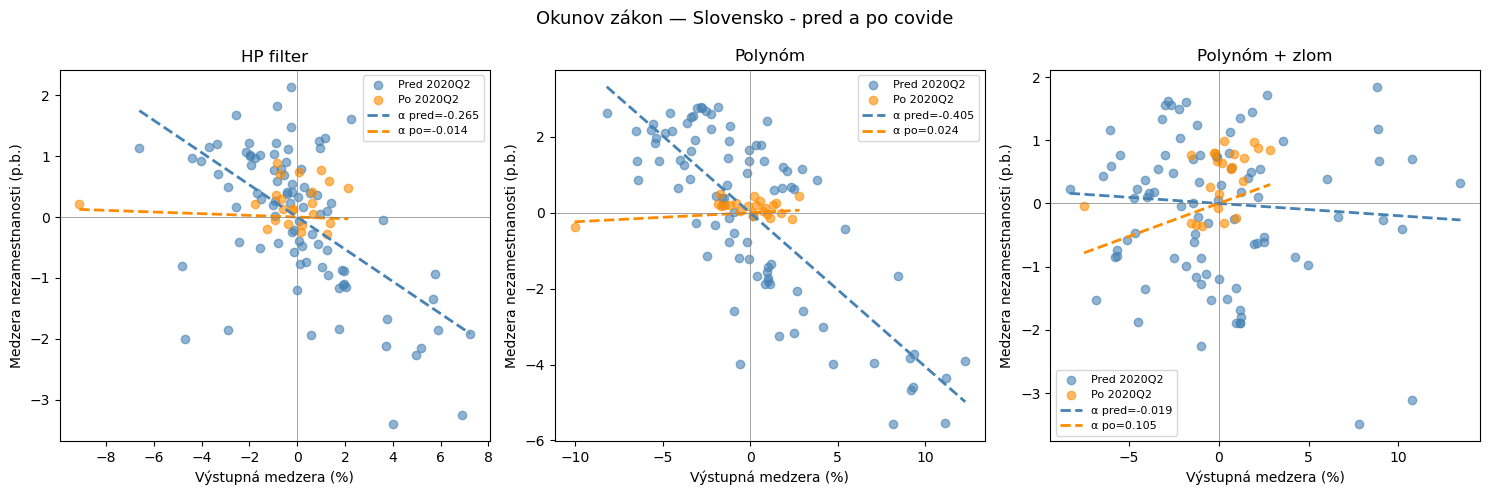

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metody = ['HP filter', 'Polynóm', 'Polynóm + zlom']

for ax, metoda in zip(axes, metody):
    y_cycle = df_cycles_gdp[metoda] * 100
    u_cycle = df_cycles_unemp[metoda]
    
    pre  = df.index < COVID_BREAK
    post = df.index >= COVID_BREAK
    
    ax.scatter(y_cycle[pre],  u_cycle[pre],  color='steelblue',  alpha=0.6, label='Pred 2020Q2')
    ax.scatter(y_cycle[post], u_cycle[post], color='darkorange', alpha=0.6, label='Po 2020Q2')
    
    # Regresná priamka pre každé obdobie
    for mask, color, label in [
        (pre,  'steelblue',  'pred'),
        (post, 'darkorange', 'po')
    ]:
        m = OLS(u_cycle[mask], y_cycle[mask]).fit()
        x_line = np.linspace(y_cycle[mask].min(), y_cycle[mask].max(), 100)
        ax.plot(x_line, m.params[0] * x_line, color=color, 
                linewidth=2, linestyle='--',
                label=f'α {label}={m.params[0]:.3f}')
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Výstupná medzera (%)')
    ax.set_ylabel('Medzera nezamestnanosti (p.b.)')
    ax.set_title(metoda)
    ax.legend(fontsize=8)

plt.suptitle('Okunov zákon — Slovensko - pred a po covide', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/Okun_summary_covid.png',dpi = 150)
plt.show()

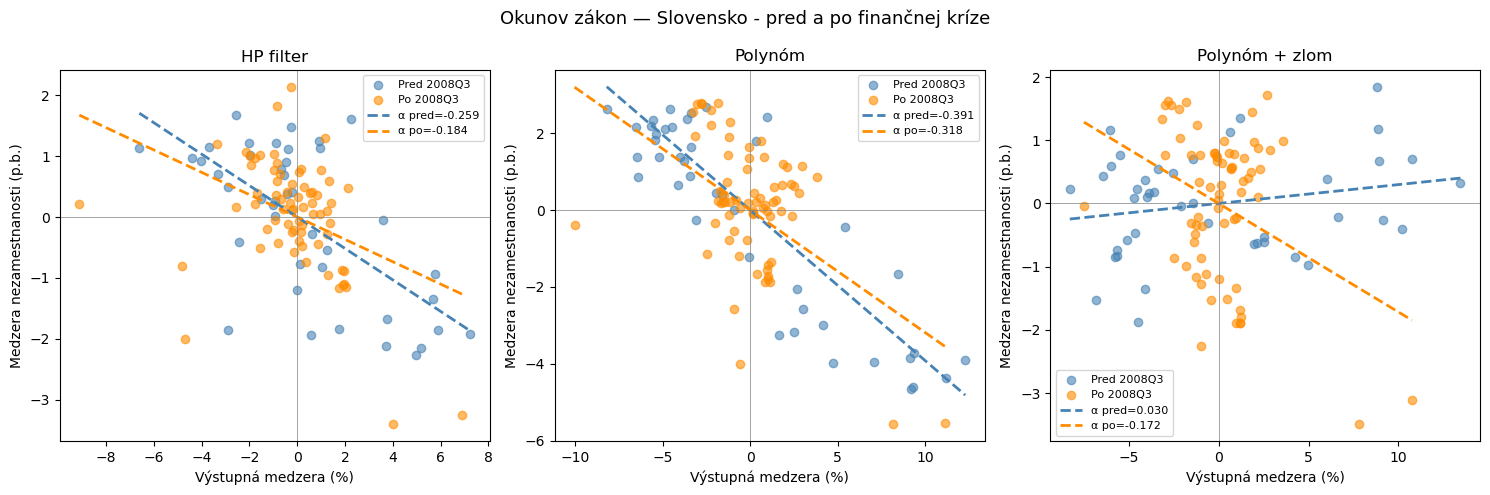

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metody = ['HP filter', 'Polynóm', 'Polynóm + zlom']

for ax, metoda in zip(axes, metody):
    y_cycle = df_cycles_gdp[metoda] * 100
    u_cycle = df_cycles_unemp[metoda]
    
    pre  = df.index < FINANCE_BREAK
    post = df.index >= FINANCE_BREAK
    
    ax.scatter(y_cycle[pre],  u_cycle[pre],  color='steelblue',  alpha=0.6, label='Pred 2008Q3')
    ax.scatter(y_cycle[post], u_cycle[post], color='darkorange', alpha=0.6, label='Po 2008Q3')
    
    # Regresná priamka pre každé obdobie
    for mask, color, label in [
        (pre,  'steelblue',  'pred'),
        (post, 'darkorange', 'po')
    ]:
        m = OLS(u_cycle[mask], y_cycle[mask]).fit()
        x_line = np.linspace(y_cycle[mask].min(), y_cycle[mask].max(), 100)
        ax.plot(x_line, m.params[0] * x_line, color=color, 
                linewidth=2, linestyle='--',
                label=f'α {label}={m.params[0]:.3f}')
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Výstupná medzera (%)')
    ax.set_ylabel('Medzera nezamestnanosti (p.b.)')
    ax.set_title(metoda)
    ax.legend(fontsize=8)

plt.suptitle('Okunov zákon — Slovensko - pred a po finančnej kríze', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/Okun_summary_finance.png',dpi = 150)
plt.show()